In [1]:
from transformers import AutoTokenizer, AutoModel
import torch

In [2]:
import transformers
print(transformers.__version__)

4.41.2


In [3]:
import sys
print(sys.executable)

c:\Users\adilu\anaconda3\envs\tp4_clean\python.exe


In [4]:
# model_name = "distilbert-base-uncased"

# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = TFAutoModel.from_pretrained(model_name)

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

# model = AutoModel.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True
)
print("Model loaded successfully")
# model = AutoModel.from_pretrained(
#     model_name,
#     output_attentions=True
# )


Model loaded successfully


In [5]:
texts = [
    "Transformers are powerful models",
    "Deep learning changes NLP"
]

In [6]:
inputs = tokenizer(
    texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

In [7]:
outputs = model(**inputs)

In [8]:
print(outputs.last_hidden_state.shape)

torch.Size([2, 7, 768])


In [9]:
cls_embedding = outputs.last_hidden_state[:, 0, :]
print(cls_embedding.shape)

torch.Size([2, 768])


In [10]:
attention = model(**inputs, output_attentions=True)

attentions = attention.attentions

print(len(attentions))

6


In [11]:
layer_attention = attentions[0]

print(layer_attention.shape)


torch.Size([2, 12, 7, 7])


Interprétation (TRÈS IMPORTANT)

Dans ton notebook tu écris :

👉 ce que ça veut dire :

chaque mot regarde les autres mots
matrice attention = relations entre tokens
plus la valeur est grande → plus important

Visualisation simple (option bonus)

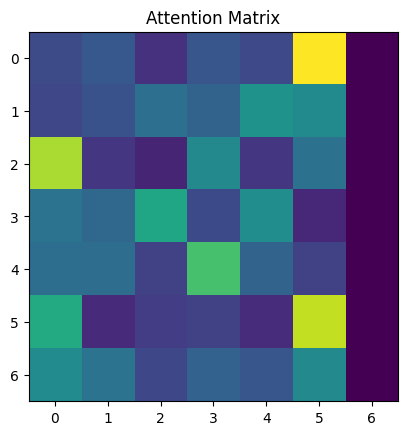

In [12]:
import matplotlib.pyplot as plt

plt.imshow(layer_attention[0][0].detach().numpy())

plt.title("Attention Matrix")

plt.show()